/tmp/ipykernel_6875/311125717.py:100: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6875/311125717.py:101: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) DejaVu Sans.
  plt.savefig("day11_physical.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


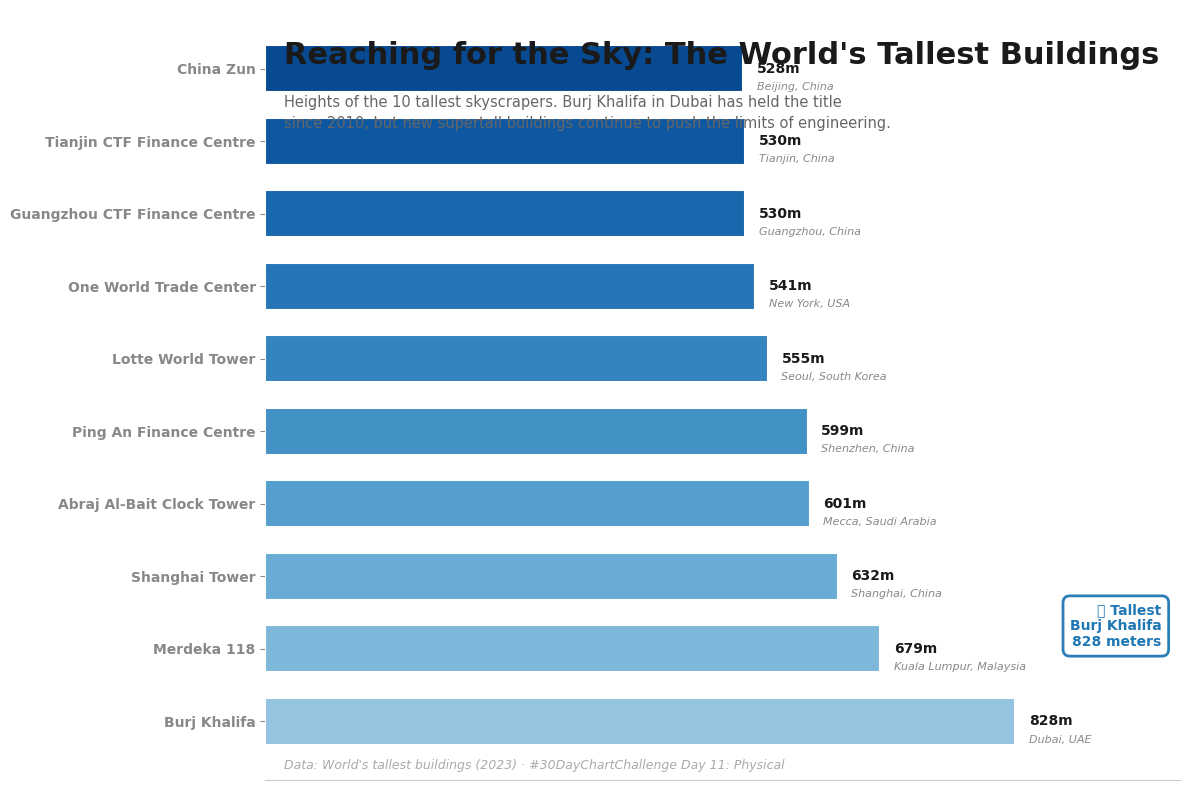

In [1]:
"""
#30DayChartChallenge — Day 11: Physical
"The World's Tallest Buildings" — physical measurements and scale
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Heights of world's tallest skyscrapers (2023)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — World's tallest buildings (meters)
# ---------------------------------------------------------------------------
data = {
    "Building": [
        "Burj Khalifa",
        "Merdeka 118",
        "Shanghai Tower",
        "Abraj Al-Bait Clock Tower",
        "Ping An Finance Centre",
        "Lotte World Tower",
        "One World Trade Center",
        "Guangzhou CTF Finance Centre",
        "Tianjin CTF Finance Centre",
        "China Zun"
    ],
    "City": [
        "Dubai, UAE",
        "Kuala Lumpur, Malaysia",
        "Shanghai, China",
        "Mecca, Saudi Arabia",
        "Shenzhen, China",
        "Seoul, South Korea",
        "New York, USA",
        "Guangzhou, China",
        "Tianjin, China",
        "Beijing, China"
    ],
    "Height_m": [828, 678.9, 632, 601, 599, 555, 541, 530, 530, 528]
}

df = pd.DataFrame(data)

# ---------------------------------------------------------------------------
# 2. PLOT
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Color palette: gradient from light to dark blue
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df)))

# Horizontal bar chart
bars = ax.barh(range(len(df)), df["Height_m"], height=0.65, 
               color=colors, edgecolor="white", linewidth=1.5, zorder=3)

# Add value labels and city info
for i, (idx, row) in enumerate(df.iterrows()):
    ax.text(row["Height_m"] + 15, i, f"{row['Height_m']:.0f}m",
            fontsize=10, fontweight="600", color="#1a1a1a", va="center")
    ax.text(row["Height_m"] + 15, i - 0.25, row["City"],
            fontsize=8, color="#888888", va="center", style="italic")

# Y-axis labels
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["Building"], fontsize=11, fontweight="600", color="#1a1a1a")

# Minimal styling
ax.set_xlim(0, df["Height_m"].max() * 1.22)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.xaxis.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.set_xticks([])
ax.tick_params(colors="#888888", labelsize=10)

# Title & subtitle
ax.text(0.02, 0.96, "Reaching for the Sky: The World's Tallest Buildings",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.89,
        "Heights of the 10 tallest skyscrapers. Burj Khalifa in Dubai has held the title\n"
        "since 2010, but new supertall buildings continue to push the limits of engineering.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Highlight the tallest
tallest = df.iloc[0]
ax.text(0.98, 0.20, f"🏢 Tallest\n{tallest['Building']}\n{tallest['Height_m']:.0f} meters",
        fontsize=10, fontweight="bold", color="#1f77b4", transform=ax.transAxes, 
        ha="right", va="center", bbox=dict(boxstyle="round,pad=0.5",
        facecolor="#fff", edgecolor="#1f77b4", linewidth=2, alpha=0.95))

# Source
ax.text(0.02, 0.01,
        "Data: World's tallest buildings (2023) · #30DayChartChallenge Day 11: Physical",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day11_physical.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()